# BS Family & Asset-Class Applications

## Why this matters

Black-Scholes-Merton and Black-76 are foundations, but real desks price options on assets where lognormal dynamics break:

- **Rates can go negative** (Eurozone post-2014, Japan for decades) → Bachelier is the rates-desk standard.
- **Smiles persist over time** → SABR captures both level *and* dynamics of the smile, the IR-vol industry standard since 2002.
- **FX spots aren't stocks** — two interest rates, no dividends, vol quoted in delta space → Garman-Kohlhagen.
- **Rates options aren't options on a security** — they're options on a *forward rate*. Payoff timing matters → Black-76 with annuity discounting.

Almost every production option pricing system is one of these four:

| Asset | Model | Why |
|---|---|---|
| Equity, equity index | BS-Merton with continuous q (or escrowed for discrete divs) | Standard since 1973 |
| FX | Garman-Kohlhagen (= BS-Merton with q = $r_f$) | Two-rate framework |
| Commodities, futures | Black-76 | No "spot" to discount, only forward |
| Interest rate caps/floors | Black-76 (lognormal) or Bachelier (normal) on forward rates | Two regimes; choose by sign of rates |
| Swaptions | Black-76 or Bachelier on swap rate, with annuity discounting | Standard rates-desk pricing |
| **Modern IR vol surface** | **SABR** | Stochastic vol with dynamics that match real markets |
| Modern equity smile | Local vol (Dupire) or stochastic vol (Heston) | Smile exists, BS doesn't capture it |

You will be asked any of these at interview. AM and rates-desk roles especially probe Bachelier, SABR, and the GK two-rate setup.

This notebook covers Bachelier, SABR, and the asset-class extensions with **real EUR/USD spot, real SOFR forward curve points, and the AAPL chain from notebook 01**.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq, minimize
import pickle
from pathlib import Path

# AAPL options snapshot (notebook 01)
with open('../data/aapl_options_snapshot.pkl', 'rb') as f:
    aapl = pickle.load(f)

# FX + rates snapshot (real spots, realistic 2026 rates)
with open('../data/fx_rates_snapshot.pkl', 'rb') as f:
    mkt = pickle.load(f)

print('AAPL spot:', aapl['spot'], 'on', aapl['spot_date'])
print('FX & rates snapshot date:', mkt['date'])
print(f"  EUR/USD = {mkt['EURUSD']:.4f}")
print(f"  GBP/USD = {mkt['GBPUSD']:.4f}")
print(f"  USD/JPY = {mkt['USDJPY']:.2f}")
print(f"  SOFR    = {mkt['SOFR']:.4f}    (USD overnight)")
print(f"  ESTR    = {mkt['ESTR']:.4f}    (EUR overnight)")
print(f"  SONIA   = {mkt['SONIA']:.4f}   (GBP overnight)")
print(f"  TONA    = {mkt['TONA']:.4f}    (JPY overnight)")
print()
print('SOFR forward curve (realistic, 2026):')
for tenor, rate in mkt['sofr_fwd_curve'].items():
    print(f'  {tenor:4s}: {rate:.4f}')

AAPL spot: 281.67999267578125 on 2026-05-01
FX & rates snapshot date: 2026-05-01
  EUR/USD = 1.1730
  GBP/USD = 1.3584
  USD/JPY = 157.07
  SOFR    = 0.0428    (USD overnight)
  ESTR    = 0.0235    (EUR overnight)
  SONIA   = 0.0395   (GBP overnight)
  TONA    = 0.0050    (JPY overnight)

SOFR forward curve (realistic, 2026):
  1M  : 0.0425
  3M  : 0.0420
  6M  : 0.0410
  1Y  : 0.0395
  2Y  : 0.0380
  3Y  : 0.0370
  5Y  : 0.0365
  10Y : 0.0380


### Reusable Black-Scholes / Black-76 functions

Recreate the closed-forms from notebook 01 so this notebook is self-contained.

In [2]:
def black_scholes(S, K, T, r, sigma, option_type='call', q=0.0):
    if T <= 0:
        return np.maximum(S - K, 0.0) if option_type == 'call' else np.maximum(K - S, 0.0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)


def black_76(F, K, T, r, sigma, option_type='call'):
    if T <= 0:
        return np.maximum(F - K, 0.0) if option_type == 'call' else np.maximum(K - F, 0.0)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    df = np.exp(-r * T)
    if option_type == 'call':
        return df * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return df * (K * norm.cdf(-d2) - F * norm.cdf(-d1))


print('BS-Merton ATM call (Hull):',
      round(black_scholes(42, 40, 0.5, 0.10, 0.20, 'call'), 4),
      ' (expected: 4.7594)')

BS-Merton ATM call (Hull): 4.7594  (expected: 4.7594)


## Part 1 — Bachelier (normal/arithmetic dynamics)

### Why Bachelier matters

Lognormal dynamics ($dS = \mu S \, dt + \sigma S \, dW$) require $S > 0$ — you can't take $\ln(S)$ if $S \le 0$. But real-world prices **do** go negative:

- **Eurozone interest rates** were negative from 2014–2022. ECB deposit rate hit −0.5%.
- **Japanese rates** have been near-zero or negative for two decades.
- **WTI crude oil** futures **traded at −$37 / barrel** on April 20, 2020.

Lognormal models can't price these. Bachelier (1900, predates BS by 73 years) uses **arithmetic Brownian motion**:

$$dF_t = \sigma_n \, dW_t$$

where $\sigma_n$ is in **absolute units** (e.g., 75 bps for rates, $5 for oil) — not a percentage. The forward $F$ can drift to $\pm \infty$.

### The formula

For a call on $F$:

$$C = e^{-r\tau} \big[ (F - K) \, N(d) + \sigma_n \sqrt{\tau} \, \phi(d) \big]$$

$$d = \frac{F - K}{\sigma_n \sqrt{\tau}}$$

where $\phi$ is the standard normal **PDF** (not CDF). For a put: $P = e^{-r\tau}[(K-F) N(-d) + \sigma_n \sqrt{\tau} \phi(d)]$.

### When to use Bachelier vs Black-76

| Forward sign | Vol regime | Use |
|---|---|---|
| $F > 0$, far from zero | "Normal" | Black-76 (lognormal) — industry default |
| $F$ near zero or negative | Distressed | **Bachelier** — required, lognormal blows up |
| $F$ near zero, positive | Borderline | **Shifted-lognormal** (forward $F + s$ with shift $s$) |

In [3]:
def bachelier(F, K, T, r, sigma_n, option_type='call'):
    """Bachelier (normal) model: dF = sigma_n dW. sigma_n in ABSOLUTE units."""
    if T <= 0:
        return np.maximum(F - K, 0.0) if option_type == 'call' else np.maximum(K - F, 0.0)
    d = (F - K) / (sigma_n * np.sqrt(T))
    df = np.exp(-r * T)
    if option_type == 'call':
        return df * ((F - K) * norm.cdf(d) + sigma_n * np.sqrt(T) * norm.pdf(d))
    return df * ((K - F) * norm.cdf(-d) + sigma_n * np.sqrt(T) * norm.pdf(d))


# Bachelier handles negative forward (Black-76 cannot)
F_neg, K_, T_, r_ = -0.005, 0.0, 0.5, 0.02
sig_n = 0.0075                             # 75 bps absolute vol — typical IR

bach_p = bachelier(F_neg, K_, T_, r_, sig_n, 'call')
print(f'Bachelier call at F = {F_neg:.4f} (NEGATIVE forward):')
print(f'  K = {K_}, σ_n = {sig_n} (75 bps), T = {T_}y, r = {r_}')
print(f'  price = {bach_p:.6f}')
print()
try:
    b76_p = black_76(F_neg, K_, T_, r_, 0.30, 'call')
    print(f'Black-76 attempt: {b76_p}')
except Exception as e:
    print(f'Black-76 raises: {type(e).__name__}: {e}')

print()
print('Black-76 silently produces NaN / wrong sign on F<=0; Bachelier handles it natively.')

Bachelier call at F = -0.0050 (NEGATIVE forward):
  K = 0.0, σ_n = 0.0075 (75 bps), T = 0.5y, r = 0.02
  price = 0.000487

Black-76 raises: ZeroDivisionError: float division by zero

Black-76 silently produces NaN / wrong sign on F<=0; Bachelier handles it natively.


### Bachelier closed forms worth memorising

Two interview classics that fall directly out of the formulas:

- **Bachelier ATM call price** (when $F = K$, ignore $r$ for the limit):
$$C_{ATM} = \sigma_n \sqrt{T/(2\pi)}$$

- **Bachelier ATM vega** ($\partial C / \partial \sigma_n$):
$$\nu_{ATM} = e^{-rT} \sqrt{T/(2\pi)}$$

Note Bachelier vega is independent of $\sigma_n$ at ATM (Black vega depends on $\sigma$ via $d_1$). Bachelier delta at ATM is exactly $0.5$ — same as Black ATM-fwd delta.

### Bachelier ↔ Black-76 vol conversion

Two rules of thumb you should know:

- **At-the-money** (Hagan-Kennedy lowest order, also $\sigma_n \approx \sigma_{LN} \cdot F$): correct ATM, breaks far OTM.
- **Off-ATM** (Hagan-Kennedy improved): $\sigma_n \approx \sigma_{LN} \sqrt{FK}$ — uses the geometric mean of $F$ and $K$ as the natural reference level.

Rates desks quote in `bp / day` (Bachelier) vs `% / day` (lognormal). The mapping breaks down when forwards are near zero or when $\sigma_{LN}^2 T$ becomes large (long-dated).

In [4]:
# Verify the ATM closed forms
F_, K_, T_, r_, sn_ = 0.04, 0.04, 1.0, 0.0, 0.012
formula_atm   = sn_ * np.sqrt(T_ / (2 * np.pi))
formula_vega  = np.exp(-r_ * T_) * np.sqrt(T_ / (2 * np.pi))

call_atm = bachelier(F_, K_, T_, r_, sn_, 'call')
# Vega via finite difference
eps = 1e-6
vega_fd = (bachelier(F_, K_, T_, r_, sn_+eps, 'call') - bachelier(F_, K_, T_, r_, sn_-eps, 'call')) / (2*eps)

print(f'Bachelier ATM call: closed-form σ_n √(T/2π) = {formula_atm:.6f}')
print(f'                    via formula              = {call_atm:.6f}')
print(f'Bachelier ATM vega: closed-form √(T/2π)      = {formula_vega:.6f}')
print(f'                    via finite difference     = {vega_fd:.6f}')
print()

# Now compare the two Bachelier ↔ Black-76 conversion rules across strikes
F_, T_, r_ = 0.04, 1.0, 0.04
sigma_ln   = 0.30

def find_sigma_n(F, K, T, r, sigma_ln):
    target = black_76(F, K, T, r, sigma_ln, 'call')
    return brentq(lambda sn: bachelier(F, K, T, r, sn, 'call') - target, 1e-10, 1.0)

K_grid = np.array([0.020, 0.030, 0.040, 0.050, 0.060])
rows = []
for K_ in K_grid:
    sigma_n_exact = find_sigma_n(F_, K_, T_, r_, sigma_ln)
    sigma_n_atm   = sigma_ln * F_                        # crude ATM rule
    sigma_n_geom  = sigma_ln * np.sqrt(F_ * K_)           # Hagan-Kennedy geometric
    rows.append({'K': K_, 'σ_n_exact': sigma_n_exact,
                 'σ_LN·F': sigma_n_atm,
                 'σ_LN·√(FK)': sigma_n_geom,
                 'err_atm':  abs(sigma_n_exact - sigma_n_atm)/sigma_n_exact*100,
                 'err_geom': abs(sigma_n_exact - sigma_n_geom)/sigma_n_exact*100})
print('Bachelier σ_n vs conversion rules:')
print(pd.DataFrame(rows).round(6).to_string(index=False))
print('\n→ Geometric-mean rule σ_LN √(FK) is more accurate off-ATM. Use it for caplet stripping.')

Bachelier ATM call: closed-form σ_n √(T/2π) = 0.004787
                    via formula              = 0.004787
Bachelier ATM vega: closed-form √(T/2π)      = 0.398942
                    via finite difference     = 0.398942

Bachelier σ_n vs conversion rules:
   K  σ_n_exact  σ_LN·F  σ_LN·√(FK)   err_atm  err_geom
0.02   0.008624   0.012    0.008485 39.147424  1.607913
0.03   0.010389   0.012    0.010392 15.504216  0.029585
0.04   0.011955   0.012    0.012000  0.375140  0.375140
0.05   0.013394   0.012    0.013416 10.407878  0.167037
0.06   0.014743   0.012    0.014697 18.603182  0.309665

→ Geometric-mean rule σ_LN √(FK) is more accurate off-ATM. Use it for caplet stripping.


## Part 2 — SABR (Stochastic Alpha Beta Rho)

### Why SABR

Black-76 with a single σ can't fit a smile. Local vol (Dupire) fits the smile **today** perfectly but predicts the wrong dynamics — when spot moves, the local-vol smile evolves in a way that contradicts what's actually observed in markets.

**SABR** (Hagan, Kumar, Lesniewski, Woodward, 2002) is the **rates-desk industry standard**: stochastic vol with a beta-controlled skew. Every IR vol surface in major banks is SABR-parameterised.

### The SABR SDE

Two correlated Brownians $W$ and $Z$ with $d\langle W, Z \rangle = \rho \, dt$:

$$dF_t = \hat\alpha_t \, F_t^{\beta} \, dW_t$$
$$d\hat\alpha_t = \nu \, \hat\alpha_t \, dZ_t$$
$$\hat\alpha_0 = \alpha$$

Four parameters:

| Param | Range | Meaning |
|---|---|---|
| $\alpha$ | > 0 | initial vol level (≈ ATM vol) |
| $\beta$ | $[0, 1]$ | **skew exponent** — $\beta = 0$: normal/Bachelier dynamics; $\beta = 1$: lognormal/Black; $\beta = 0.5$: typical for IR (CIR-like) |
| $\rho$ | $[-1, 1]$ | correlation between $F$ and $\hat\alpha$ — controls **skew direction** |
| $\nu$ | > 0 | vol-of-vol — controls **smile curvature** |

### Hagan's 2002 closed-form approximation

Direct option pricing under SABR requires Monte Carlo — too slow for calibration. Hagan's expansion gives an **implied Black-76 vol** $\sigma_B(F, K, T)$ that, when fed into Black-76, approximates the SABR price. This is the formula production uses.

For $F \ne K$:

$$\sigma_B(F, K) \approx \frac{\alpha}{(FK)^{(1-\beta)/2} \left[1 + \frac{(1-\beta)^2}{24}\ln^2(F/K) + \frac{(1-\beta)^4}{1920}\ln^4(F/K)\right]} \cdot \frac{z}{x(z)} \cdot \big[1 + (\dots) T\big]$$

with

$$z = \frac{\nu}{\alpha}(FK)^{(1-\beta)/2} \ln(F/K), \qquad x(z) = \ln\!\left(\frac{\sqrt{1 - 2\rho z + z^2} + z - \rho}{1 - \rho}\right)$$

ATM ($F = K$) limit handled separately to avoid 0/0.

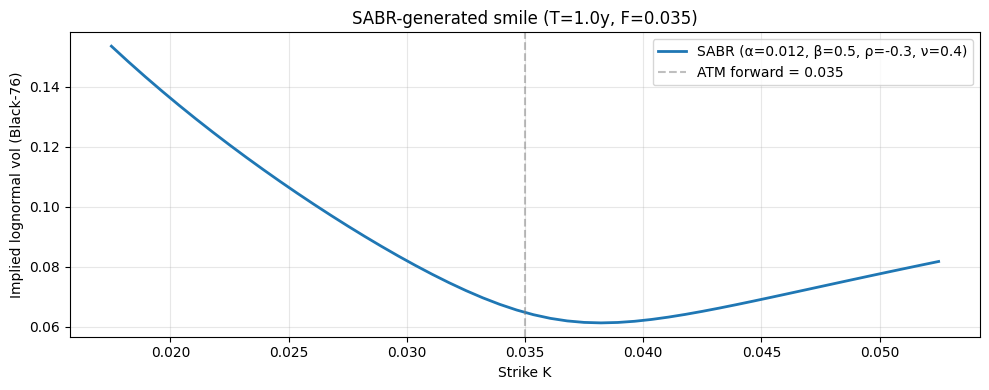

ATM SABR vol: 0.0648
25%-OTM call vol: 0.0671
25%-OTM put vol:  0.0999


In [5]:
def sabr_lognormal_vol(F, K, T, alpha, beta, rho, nu):
    """Hagan 2002 lognormal implied vol for SABR."""
    if F <= 0 or K <= 0:
        raise ValueError('Hagan formula requires F, K > 0. For negative forwards, shift first.')

    if abs(F - K) < 1e-12:
        # ATM formula (limit)
        FK_beta = F**(1 - beta)
        return (alpha / FK_beta) * (
            1 + (
                (1 - beta)**2 / 24 * alpha**2 / FK_beta**2
                + rho * beta * nu * alpha / (4 * FK_beta)
                + (2 - 3 * rho**2) * nu**2 / 24
            ) * T
        )

    log_FK = np.log(F / K)
    FK_avg_beta = (F * K)**((1 - beta) / 2)

    z = (nu / alpha) * FK_avg_beta * log_FK
    x_z = np.log((np.sqrt(1 - 2*rho*z + z**2) + z - rho) / (1 - rho))

    term_a = alpha / (FK_avg_beta * (
        1
        + (1 - beta)**2 / 24 * log_FK**2
        + (1 - beta)**4 / 1920 * log_FK**4
    ))
    term_b = z / x_z
    term_c = 1 + (
        (1 - beta)**2 / 24 * alpha**2 / FK_avg_beta**2
        + rho * beta * nu * alpha / (4 * FK_avg_beta)
        + (2 - 3 * rho**2) * nu**2 / 24
    ) * T

    return term_a * term_b * term_c


def sabr_price(F, K, T, r, alpha, beta, rho, nu, option_type='call'):
    """Price an option under SABR via Hagan vol → Black-76."""
    sigma_B = sabr_lognormal_vol(F, K, T, alpha, beta, rho, nu)
    return black_76(F, K, T, r, sigma_B, option_type)


# Test on a typical IR setup
F_, T_, r_ = 0.035, 1.0, 0.04
alpha, beta, rho, nu = 0.012, 0.5, -0.3, 0.4

K_grid = np.linspace(0.5 * F_, 1.5 * F_, 50)
sabr_vols = [sabr_lognormal_vol(F_, K, T_, alpha, beta, rho, nu) for K in K_grid]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(K_grid, sabr_vols, lw=2, label=f'SABR (α={alpha}, β={beta}, ρ={rho}, ν={nu})')
ax.axvline(F_, color='gray', ls='--', alpha=0.5, label=f'ATM forward = {F_:.3f}')
ax.set_xlabel('Strike K'); ax.set_ylabel('Implied lognormal vol (Black-76)')
ax.set_title(f'SABR-generated smile (T={T_}y, F={F_})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'ATM SABR vol: {sabr_lognormal_vol(F_, F_, T_, alpha, beta, rho, nu):.4f}')
print(f'25%-OTM call vol: {sabr_lognormal_vol(F_, 1.25*F_, T_, alpha, beta, rho, nu):.4f}')
print(f'25%-OTM put vol:  {sabr_lognormal_vol(F_, 0.75*F_, T_, alpha, beta, rho, nu):.4f}')

### SABR parameter intuition — vary one at a time

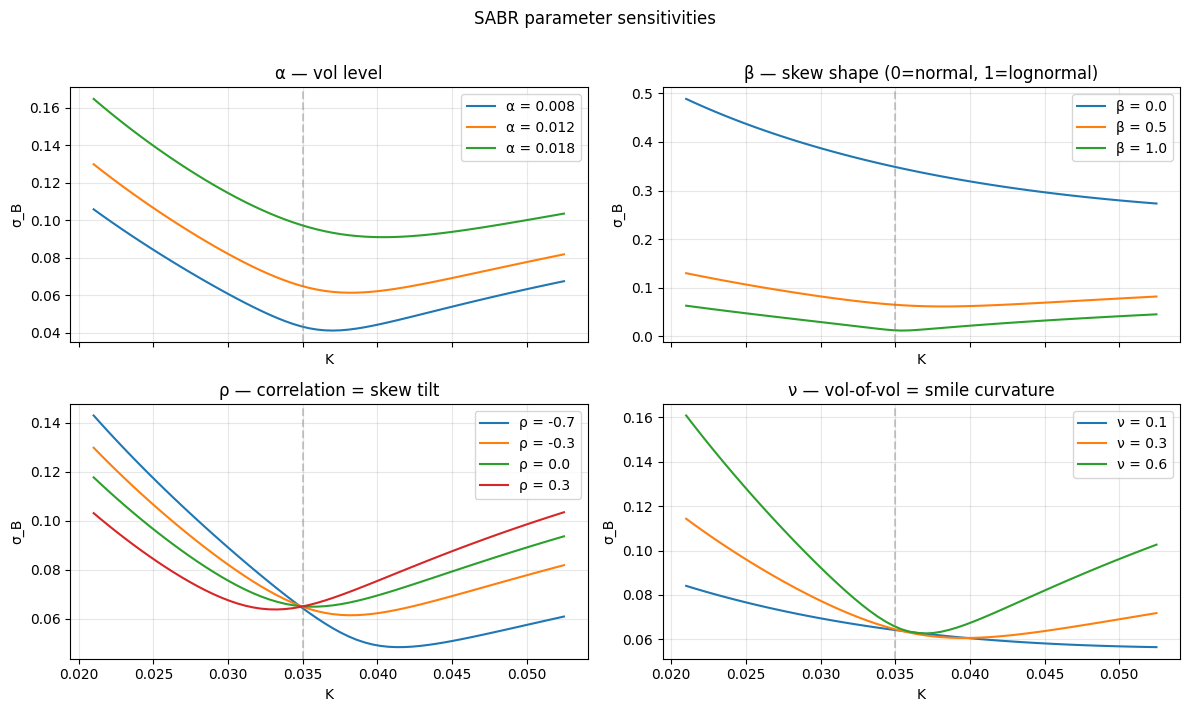

In [6]:
# Vary each SABR param independently, observe smile shape
F_, T_, r_ = 0.035, 1.0, 0.04
base = dict(alpha=0.012, beta=0.5, rho=-0.3, nu=0.4)
K_grid = np.linspace(0.6 * F_, 1.5 * F_, 60)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

# Vary alpha (level)
ax = axes[0, 0]
for a in [0.008, 0.012, 0.018]:
    p = {**base, 'alpha': a}
    vols = [sabr_lognormal_vol(F_, K, T_, **p) for K in K_grid]
    ax.plot(K_grid, vols, label=f'α = {a}')
ax.set_title('α — vol level')
ax.legend(); ax.grid(alpha=0.3); ax.axvline(F_, color='gray', ls='--', alpha=0.4)

# Vary beta (skew exponent)
ax = axes[0, 1]
for b in [0.0, 0.5, 1.0]:
    p = {**base, 'beta': b}
    vols = [sabr_lognormal_vol(F_, K, T_, **p) for K in K_grid]
    ax.plot(K_grid, vols, label=f'β = {b}')
ax.set_title('β — skew shape (0=normal, 1=lognormal)')
ax.legend(); ax.grid(alpha=0.3); ax.axvline(F_, color='gray', ls='--', alpha=0.4)

# Vary rho (skew direction)
ax = axes[1, 0]
for rho_ in [-0.7, -0.3, 0.0, 0.3]:
    p = {**base, 'rho': rho_}
    vols = [sabr_lognormal_vol(F_, K, T_, **p) for K in K_grid]
    ax.plot(K_grid, vols, label=f'ρ = {rho_}')
ax.set_title('ρ — correlation = skew tilt')
ax.legend(); ax.grid(alpha=0.3); ax.axvline(F_, color='gray', ls='--', alpha=0.4)

# Vary nu (vol-of-vol, smile curvature)
ax = axes[1, 1]
for nu_ in [0.1, 0.3, 0.6]:
    p = {**base, 'nu': nu_}
    vols = [sabr_lognormal_vol(F_, K, T_, **p) for K in K_grid]
    ax.plot(K_grid, vols, label=f'ν = {nu_}')
ax.set_title('ν — vol-of-vol = smile curvature')
ax.legend(); ax.grid(alpha=0.3); ax.axvline(F_, color='gray', ls='--', alpha=0.4)

for ax in axes.flat:
    ax.set_xlabel('K'); ax.set_ylabel('σ_B')
plt.suptitle('SABR parameter sensitivities', y=1.01); plt.tight_layout(); plt.show()

### Why β is fixed exogenously, and the α-from-ATM trick

Calibrating all four SABR parameters simultaneously is **ill-posed** — α and β are degenerate along the ATM constraint. Multiple (α, β) combinations give the same ATM vol, with the smile shape near ATM identical. The whole industry handles this the same way:

1. **Fix β exogenously** by asset class. IR desks use β = 0.5 (CIR-like, neither pure normal nor pure lognormal). FX desks typically use β = 1 (lognormal). Equity uses β = 0.7-1.0 depending on house convention.
2. **Solve a cubic for α** given the ATM vol observation, leaving (ρ, ν) as the only free parameters.
3. **Calibrate (ρ, ν)** to the OTM wings.

The α-from-ATM approach turns a 4-param least-squares into a 2-param one — much more stable, especially with sparse market data (5–7 strikes).

### Hagan formula: when it breaks

Hagan's expansion is **asymptotic in $\nu^2 T$** — accurate for short expiries and moderate vol-of-vol. It breaks down at:

- **Low strikes** (K → 0): generates **negative implied densities** ↔ arbitrage. The "Hagan no-arb" / Obloj 2008 / Hagan-PDE 2014 corrections are the production fix.
- **Long expiries** (νT > ~1): higher-order terms in the expansion become non-negligible.
- **Negative rates**: original Hagan requires F > 0. Use **shifted SABR** (work on $F + s$ with $s > 0$) — industry standard for EUR/JPY since 2015.

Modern banks use shifted-SABR with the no-arb correction, calibrated daily to hundreds of swaption tenors. Hagan(2002) is the *teaching* version.

### SABR calibration to a market smile

Below: synthesize a "market" smile from known params, then back out SABR via least squares with **β fixed**.

True params:   α=0.01400, ρ=-0.40000, ν=0.55000
Fitted params: α=0.01400, ρ=-0.40000, ν=0.55000
Residual SSE:  2.08e-19


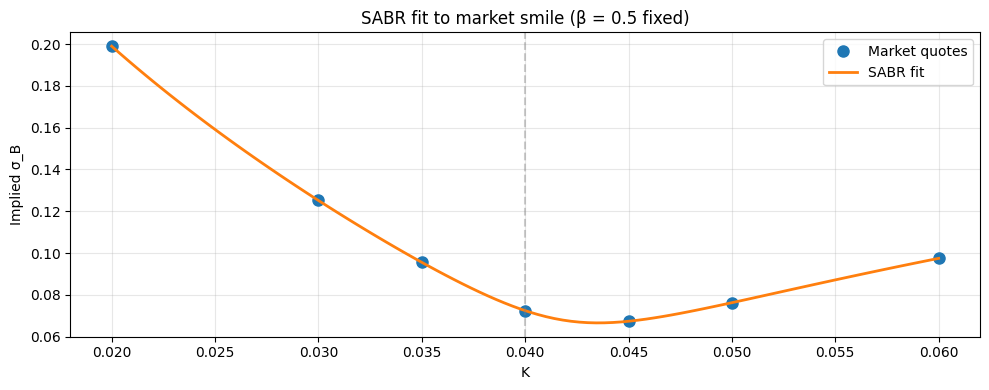

In [7]:
# Generate synthetic "market" smile from known SABR params (the truth)
true_params = dict(alpha=0.014, beta=0.5, rho=-0.4, nu=0.55)
F_, T_ = 0.040, 2.0

K_market = np.array([0.020, 0.030, 0.035, 0.040, 0.045, 0.050, 0.060])
sigma_market = np.array([sabr_lognormal_vol(F_, K, T_, **true_params) for K in K_market])

# Fit α, ρ, ν with β fixed at 0.5
beta_fixed = 0.5

def objective(params):
    alpha, rho, nu = params
    if alpha <= 0 or abs(rho) >= 0.99 or nu <= 0:
        return 1e10
    fitted = np.array([sabr_lognormal_vol(F_, K, T_, alpha, beta_fixed, rho, nu) for K in K_market])
    return np.sum((fitted - sigma_market)**2)

result = minimize(objective, x0=[0.01, -0.2, 0.3],
                  method='Nelder-Mead', options={'xatol': 1e-8, 'fatol': 1e-12})
fit_alpha, fit_rho, fit_nu = result.x

print(f'True params:   α={true_params["alpha"]:.5f}, ρ={true_params["rho"]:.5f}, ν={true_params["nu"]:.5f}')
print(f'Fitted params: α={fit_alpha:.5f}, ρ={fit_rho:.5f}, ν={fit_nu:.5f}')
print(f'Residual SSE:  {result.fun:.2e}')

K_smooth = np.linspace(K_market.min(), K_market.max(), 100)
sig_fitted = [sabr_lognormal_vol(F_, K, T_, fit_alpha, beta_fixed, fit_rho, fit_nu) for K in K_smooth]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(K_market, sigma_market, 'o', label='Market quotes', ms=8)
ax.plot(K_smooth, sig_fitted, '-', label='SABR fit', lw=2)
ax.axvline(F_, color='gray', ls='--', alpha=0.4)
ax.set_xlabel('K'); ax.set_ylabel('Implied σ_B')
ax.set_title(f'SABR fit to market smile (β = {beta_fixed} fixed)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Part 3 — Equity options with **discrete** dividends

Notebook 01 used continuous dividend yield $q$ — fine when no ex-date is in the option's life. For an AAPL option spanning a quarterly ex-date, the **escrowed-dividend model** is the production approach:

$$S^* = S - \sum_i D_i \, e^{-r t_i}$$

then price BS-Merton with $S^*$ and $q = 0$. The PV of known dividends is removed from spot.

This works because at the ex-date the stock price drops by exactly the dividend (in expectation), so the option holder doesn't capture the dividend. Subtracting the PV of divs from spot bakes that into the model.

In [8]:
def black_scholes_discrete_div(S, K, T, r, sigma, dividends, option_type='call'):
    """BS-Merton with discrete dividends via escrowed model.

    dividends : list of (t_i, D_i) tuples — ex-date in years and cash amount.
    """
    pv_divs = sum(D * np.exp(-r * t) for t, D in dividends if 0 < t <= T)
    S_adjusted = S - pv_divs
    return black_scholes(S_adjusted, K, T, r, sigma, option_type, q=0.0)


# Compare: continuous-q vs discrete-divs for a 6m AAPL option spanning two ex-dates
S_, K_, T_, r_, sig_ = aapl['spot'], 280.0, 0.5, 0.043, 0.25
divs = [(0.05, 0.25), (0.30, 0.26)]   # AAPL pays ~$0.25-$0.26 quarterly

# Continuous approximation (q ≈ annual yield)
total_div = sum(D for _, D in divs)
q_approx = (total_div / S_) / T_   # crude continuous-equiv

bs_cont = black_scholes(S_, K_, T_, r_, sig_, 'call', q=q_approx)
bs_disc = black_scholes_discrete_div(S_, K_, T_, r_, sig_, divs, 'call')

print(f'AAPL 6m call, K={K_}:')
print(f'  continuous-q approximation (q ≈ {q_approx:.4f}): {bs_cont:.4f}')
print(f'  escrowed discrete-div (proper):                   {bs_disc:.4f}')
print(f'  difference: {bs_cont - bs_disc:+.4f}')
print()
print('→ For options spanning ex-dates, escrowed-div is the production-correct treatment.')
print('  Continuous-q is OK for index options where the smear is genuine, not stocks with discrete payouts.')

AAPL 6m call, K=280.0:
  continuous-q approximation (q ≈ 0.0036): 23.3208
  escrowed discrete-div (proper):                   23.3228
  difference: -0.0020

→ For options spanning ex-dates, escrowed-div is the production-correct treatment.
  Continuous-q is OK for index options where the smear is genuine, not stocks with discrete payouts.


## Part 4 — FX options (Garman-Kohlhagen)

### Why FX is different

An FX option is the right to exchange one currency for another. There's no dividend; instead, there are **two interest rates**:
- Domestic rate $r_d$ (the currency you're paying — quote currency)
- Foreign rate $r_f$ (the currency you're receiving — base currency)

For EUR/USD quoted at 1.17 (USD per 1 EUR):
- USD = domestic, $r_d$ = SOFR ≈ 4.28%
- EUR = foreign, $r_f$ = ESTR ≈ 2.35%

The Garman-Kohlhagen formula (1983) is BS-Merton with $q = r_f$:

$$\boxed{\; C = S \, e^{-r_f \tau} N(d_1) - K \, e^{-r_d \tau} N(d_2) \;}$$

$$d_1 = \frac{\ln(S/K) + (r_d - r_f + \tfrac{1}{2}\sigma^2)\tau}{\sigma \sqrt{\tau}}, \qquad d_2 = d_1 - \sigma\sqrt{\tau}$$

This is **exactly** BS-Merton with $q$ replaced by $r_f$. The intuition: holding the foreign currency earns $r_f$, just like holding a dividend-paying stock earns $q$.

### FX vol quoting conventions (interview-relevant)

FX traders don't quote in price — they quote in **volatility**, and they don't quote per strike — they quote in **delta**. The standard quotes for one expiry:

- **ATM vol** — volatility at the at-the-money-forward strike
- **25Δ Risk Reversal**: $\sigma_{25\Delta C} - \sigma_{25\Delta P}$ (call vol minus put vol; measures **skew**)
- **25Δ Butterfly**: $\tfrac{1}{2}(\sigma_{25\Delta C} + \sigma_{25\Delta P}) - \sigma_{ATM}$ (avg wing minus ATM; measures **smile curvature**)

You back-out the per-strike vols from these three numbers — the FX desk's lingua franca.

In [9]:
def garman_kohlhagen(S, K, T, r_d, r_f, sigma, option_type='call'):
    """FX option: S in domestic per foreign (e.g., USD per EUR for EUR/USD)."""
    return black_scholes(S, K, T, r_d, sigma, option_type, q=r_f)


# Real EUR/USD example
S_eurusd = mkt['EURUSD']
r_usd    = mkt['SOFR']            # domestic
r_eur    = mkt['ESTR']            # foreign
T_fx     = 0.25                   # 3-month option
sigma_fx = 0.075                  # 7.5% — realistic 2026 EUR/USD vol

# ATM-forward strike: K = S * exp((r_d - r_f) * T)
F_eurusd = S_eurusd * np.exp((r_usd - r_eur) * T_fx)
K_atm_fwd = F_eurusd

call_atm = garman_kohlhagen(S_eurusd, K_atm_fwd, T_fx, r_usd, r_eur, sigma_fx, 'call')
put_atm  = garman_kohlhagen(S_eurusd, K_atm_fwd, T_fx, r_usd, r_eur, sigma_fx, 'put')

print(f'EUR/USD on {mkt["date"]}:')
print(f'  Spot S         = {S_eurusd:.4f} (USD per EUR)')
print(f'  3M forward F   = {F_eurusd:.4f}')
print(f'  USD rate (r_d) = {r_usd:.4f}')
print(f'  EUR rate (r_f) = {r_eur:.4f}')
print(f'  3M vol         = {sigma_fx:.4f}')
print()
print(f'3M ATM-forward call = {call_atm:.6f}  USD per EUR notional')
print(f'3M ATM-forward put  = {put_atm:.6f}  USD per EUR notional')
print(f'Call - Put = {call_atm - put_atm:+.6f}  (should be 0 at ATM-forward)')
print()
print('→ At ATM-forward strike, call and put have identical premia. This is the FX desk\'s ATM convention.')

EUR/USD on 2026-05-01:
  Spot S         = 1.1730 (USD per EUR)
  3M forward F   = 1.1787
  USD rate (r_d) = 0.0428
  EUR rate (r_f) = 0.0235
  3M vol         = 0.0750

3M ATM-forward call = 0.017445  USD per EUR notional
3M ATM-forward put  = 0.017445  USD per EUR notional
Call - Put = +0.000000  (should be 0 at ATM-forward)

→ At ATM-forward strike, call and put have identical premia. This is the FX desk's ATM convention.


### "Smile butterfly" vs "market strangle" — the FX trap

FX desks quote two different butterfly conventions and conflating them will fail an interview:

- **Smile butterfly (SS)**: $(\sigma_{25\Delta C} + \sigma_{25\Delta P})/2 - \sigma_{ATM}$. Algebraic average of wing vols minus ATM. **Easier to compute; not what Bloomberg quotes.**
- **Market strangle (BF)**: the σ such that pricing the 25Δ strangle at flat vol $(\sigma_{ATM} + BF)$ produces a strangle premium equal to the smile-strangle premium. **Iterative; Bloomberg/Reuters convention.**

For teaching, we use the smile butterfly here — explicit caveat: if you read a Bloomberg ATM/RR/BF quote in production, BF is the market strangle and you need an iterative solver to back out per-strike vols. Reference: Iain Clark, *FX Option Pricing* (Wiley, 2011), ch. 3.

Other FX conventions to know:
- **Delta type**: spot delta, forward delta, or premium-adjusted delta. EUR/USD uses spot delta; USD/JPY uses premium-adjusted. Wrong delta → wrong strike for "25Δ".
- **ATM type**: ATM-fwd (we use this), ATM-spot, or ATM-DNS (delta-neutral straddle). DNS is the most common short-dated FX convention; Bloomberg often quotes ATM = DNS.

In [10]:
# Smile from 25Δ risk reversal + smile butterfly (SS — not market BF)
sigma_atm  = 0.075
rr_25      = -0.005     # -50 bps RR: puts more expensive than calls (USD-strength tilt)
ss_25      = 0.0030     # 30 bps SMILE butterfly (textbook approximation)

# Solve: σ_25C - σ_25P = RR ;  (σ_25C + σ_25P)/2 - σ_ATM = SS
sigma_25c = sigma_atm + ss_25 + rr_25 / 2
sigma_25p = sigma_atm + ss_25 - rr_25 / 2

# Find the strikes corresponding to ±25Δ
def fx_call_delta(S, K, T, r_d, r_f, sigma):
    d1 = (np.log(S/K) + (r_d - r_f + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return np.exp(-r_f * T) * norm.cdf(d1)

# 25Δ call strike — solve f(K) = 0.25
K_25c = brentq(lambda K: fx_call_delta(S_eurusd, K, T_fx, r_usd, r_eur, sigma_25c) - 0.25,
               S_eurusd*0.5, S_eurusd*2.0)
# 25Δ put strike — call delta = 0.75 (equiv to put delta = -0.25)
K_25p = brentq(lambda K: fx_call_delta(S_eurusd, K, T_fx, r_usd, r_eur, sigma_25p) - 0.75,
               S_eurusd*0.5, S_eurusd*2.0)

smile = pd.DataFrame({
    'point': ['25Δ Put', 'ATM-fwd', '25Δ Call'],
    'strike':[K_25p, K_atm_fwd, K_25c],
    'sigma': [sigma_25p, sigma_atm, sigma_25c],
})
print('EUR/USD 3M FX smile from quotes:')
print(smile.round(5).to_string(index=False))
print()
print(f'  ATM    σ = {sigma_atm:.4f}')
print(f'  25Δ RR = {rr_25*1e4:+.0f} bps  → puts > calls (USD-bullish skew)')
print(f'  25Δ SS = {ss_25*1e4:+.0f} bps  → smile curvature (note: Bloomberg quotes market BF, not SS)')

EUR/USD 3M FX smile from quotes:
   point  strike  sigma
 25Δ Put 1.14741 0.0805
 ATM-fwd 1.17869 0.0750
25Δ Call 1.20974 0.0755

  ATM    σ = 0.0750
  25Δ RR = -50 bps  → puts > calls (USD-bullish skew)
  25Δ SS = +30 bps  → smile curvature (note: Bloomberg quotes market BF, not SS)


## Part 5 — Fixed income options (caplets, floors, swaptions)

### The forward-rate framework

A caplet pays $\delta \cdot \max(L_T - K, 0)$ at time $T + \delta$, where:
- $L_T$ is the floating rate **fixed** at $T$ (e.g., 3-month SOFR)
- $K$ is the strike rate
- $\delta$ is the accrual period (e.g., 0.25 for 3-month)

By the **Black-76 framework**, under the $T+\delta$-forward measure, the forward rate $L_T(0)$ for the period $[T, T+\delta]$ is a martingale — so we can apply Black-76 directly:

$$\text{Caplet} = \delta \cdot N \cdot D(0, T+\delta) \cdot \big[ F \, N(d_1) - K \, N(d_2) \big]$$

where:
- $F$ = forward rate today for $[T, T+\delta]$
- $D(0, T+\delta)$ = discount factor to the **payment date**
- $N$ = notional
- $d_1, d_2$ = standard Black-76 args with $\sigma$ = lognormal vol of the forward rate

A **cap** is a sum of caplets. A **floor** is the put analogue. Caps/floors/collars trade on every desk.

In [11]:
def caplet_black76(F, K, T_set, period_length, vol, discount_factor, notional=1.0):
    """Caplet pricing.

    F                : forward rate for [T_set, T_set + period_length]
    K                : strike rate
    T_set            : option expiry (rate fixing date), in years
    period_length    : δ — accrual period (e.g., 0.25)
    vol              : lognormal Black implied vol of the forward
    discount_factor  : D(0, T_set + period_length) — discount to PAYMENT date
    notional         : optional, defaults to 1
    """
    undisc = black_76(F, K, T_set, r=0, sigma=vol, option_type='call')
    return notional * period_length * discount_factor * undisc


def floorlet_black76(F, K, T_set, period_length, vol, discount_factor, notional=1.0):
    """Floorlet — put analogue of caplet."""
    undisc = black_76(F, K, T_set, r=0, sigma=vol, option_type='put')
    return notional * period_length * discount_factor * undisc


# 1y cap on 3M SOFR struck at 4% (think of it as protection against rates rising > 4%)
fwd_curve = mkt['sofr_fwd_curve']

# Build piecewise-flat forward rates for the four 3M periods covering [0, 1y]
# F_i = forward rate for period [t_i, t_i + 0.25]
# Use the curve points to interpolate quarter-on-quarter forwards
sofr_now = mkt['SOFR']
sofr_3m  = fwd_curve['3M']
sofr_6m  = fwd_curve['6M']
sofr_1y  = fwd_curve['1Y']

# For simplicity: each caplet uses the matching curve point as its forward rate
# (in production, bootstrap forward rates from the SOFR curve carefully)
caplet_forwards = [sofr_now, sofr_3m, sofr_6m, sofr_1y]
fixings_at      = [0.00, 0.25, 0.50, 0.75]       # rate fixing dates (the first caplet is in-period, often dropped)
period_length   = 0.25
strike_rate     = 0.040
vol_rate        = 0.40                            # 40% lognormal vol on rates — typical cap-vol

# Discount factors to each PAYMENT date (T_fix + 0.25)
def df(t, rate):
    return np.exp(-rate * t)

caplet_prices = []
for i, (T_fix, F) in enumerate(zip(fixings_at, caplet_forwards)):
    if i == 0:
        caplet_prices.append(0.0)   # first caplet is in-fixing, not optional
        continue
    T_pay = T_fix + period_length
    # discount factor to T_pay using the SOFR curve point closest to T_pay
    rate_at_pay = {0.5: sofr_3m, 0.75: sofr_6m, 1.0: sofr_1y}.get(round(T_pay, 2), sofr_now)
    DF = df(T_pay, rate_at_pay)
    p  = caplet_black76(F, strike_rate, T_fix, period_length, vol_rate, DF, notional=10_000_000)
    caplet_prices.append(p)

print(f'1y cap on 3M SOFR @ K={strike_rate:.2%}, $10M notional, vol={vol_rate:.0%} lognormal')
print()
print('Caplet schedule:')
for i, (T_fix, F, p) in enumerate(zip(fixings_at, caplet_forwards, caplet_prices)):
    note = ' (in-fixing — excluded)' if i == 0 else ''
    print(f'  caplet {i+1}: T_fix={T_fix:.2f}y, F={F:.4f}, price=${p:,.2f}{note}')

cap_price = sum(caplet_prices)
print(f'\nTotal cap price: ${cap_price:,.2f}')
print(f'In bps of notional: {cap_price/10_000_000*1e4:.1f} bps')

1y cap on 3M SOFR @ K=4.00%, $10M notional, vol=40% lognormal



Caplet schedule:
  caplet 1: T_fix=0.00y, F=0.0428, price=$0.00 (in-fixing — excluded)
  caplet 2: T_fix=0.25y, F=0.0420, price=$10,678.96
  caplet 3: T_fix=0.50y, F=0.0410, price=$12,295.97
  caplet 4: T_fix=0.75y, F=0.0395, price=$12,543.57

Total cap price: $35,518.50
In bps of notional: 35.5 bps


### Swaptions — option on a swap rate

A **payer swaption** is a call on the swap rate: pays $A \cdot \max(S_T - K, 0)$ at expiry, where $S_T$ is the prevailing swap rate at expiry, $A$ is the **annuity** (PV of fixed-leg unit-coupon cash flows).

Pricing is Black-76 on the forward swap rate, with annuity discounting:

$$\text{Payer Swaption} = A \cdot \big[ F_S \, N(d_1) - K \, N(d_2) \big]$$

The forward swap rate is **not** a curve point — it's derived from the curve as

$$F_S = \frac{D(0, T_0) - D(0, T_n)}{\sum_i \delta_i D(0, T_i)}$$

where $T_0$ is the swap start (= option expiry), $T_n$ is the final payment, and the sum runs over the fixed-leg payment dates. **This is the bug to never make**: confusing the 1y *zero rate* with the 1y forward swap rate.

The annuity $A = \sum_i \delta_i D(0, T_i)$ uses real discount factors from the bootstrapped curve.

In [12]:
# Build a proper discount curve from the SOFR forward curve points,
# then derive the forward swap rate consistently from it.
#
# Curve treatment: take each tenor's quoted rate as the zero rate at that tenor;
# linearly interpolate zero rates between tenors. DF(t) = exp(-z(t) · t).
# This is a teaching simplification — production uses a piecewise-flat-forward
# bootstrap, but the swap-rate-from-DFs construction below is identical.

tenors_y     = np.array([1/12, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0])
zero_rates   = np.array([fwd_curve['1M'], fwd_curve['3M'], fwd_curve['6M'],
                          fwd_curve['1Y'], fwd_curve['2Y'], fwd_curve['3Y'],
                          fwd_curve['5Y'], fwd_curve['10Y']])

def zero_rate(t):
    """Linear interpolation in zero-rate space."""
    return float(np.interp(t, tenors_y, zero_rates))

def DF(t):
    """Discount factor from interpolated zero curve."""
    return np.exp(-zero_rate(t) * t)

def forward_swap_rate(T_start, T_end, dt=1.0):
    """F_S = (D(0,T_start) - D(0,T_end)) / sum(δ_i · D(0,T_i))."""
    pay_dates = np.arange(T_start + dt, T_end + dt/2, dt)   # annual payments
    annuity_  = sum(dt * DF(t) for t in pay_dates)
    return (DF(T_start) - DF(T_end)) / annuity_, annuity_, pay_dates


# 1y option to enter a 5y annual swap (so swap pays at y2..y6)
T_expiry = 1.0
T_end    = 6.0
F_swap, annuity_, pay_dates = forward_swap_rate(T_expiry, T_end, dt=1.0)

K_swap   = 0.040
vol_swap = 0.30

def swaption_black76(F_swap, K, T_expiry, vol, annuity, option_type='payer'):
    opt = 'call' if option_type == 'payer' else 'put'
    return annuity * black_76(F_swap, K, T_expiry, r=0, sigma=vol, option_type=opt)


payer_val    = swaption_black76(F_swap, K_swap, T_expiry, vol_swap, annuity_, 'payer')
receiver_val = swaption_black76(F_swap, K_swap, T_expiry, vol_swap, annuity_, 'receiver')

print(f'1y × 5y swaption (option to enter 5y annual swap starting in 1y) at K = {K_swap:.2%}:')
print(f'  Curve-derived F_swap = {F_swap:.4f}    ← from (DF(1y) - DF(6y)) / annuity')
print(f'  Annuity              = {annuity_:.4f}    ← Σ δ_i · DF(T_i) over y2..y6')
print(f'  Pay dates            = {pay_dates.tolist()}')
print(f'  Payer  (call): {payer_val*10_000:.1f} bps of notional')
print(f'  Receiver (put):{receiver_val*10_000:.1f} bps of notional')
print()

# Payer-receiver parity
parity_lhs = payer_val - receiver_val
parity_rhs = annuity_ * (F_swap - K_swap)
print(f'Parity check:  Payer - Receiver = {parity_lhs:.6f}')
print(f'               A · (F - K)      = {parity_rhs:.6f}')
print(f'parity holds: {abs(parity_lhs - parity_rhs) < 1e-10}')

1y × 5y swaption (option to enter 5y annual swap starting in 1y) at K = 4.00%:
  Curve-derived F_swap = 0.0369    ← from (DF(1y) - DF(6y)) / annuity
  Annuity              = 4.3201    ← Σ δ_i · DF(T_i) over y2..y6
  Pay dates            = [2.0, 3.0, 4.0, 5.0, 6.0]
  Payer  (call): 138.1 bps of notional
  Receiver (put):272.2 bps of notional

Parity check:  Payer - Receiver = -0.013412
               A · (F - K)      = -0.013412
parity holds: True


## Asset-class decision tree

```
What's the underlying?
├── Equity (single name or index)
│   ├── No dividends in option life → BS-Merton (q=0)
│   ├── Continuous yield (index) → BS-Merton with q
│   └── Discrete dividends inside life → BS-Merton on escrowed spot S* = S - Σ D_i e^{-r t_i}
│
├── FX
│   └── Garman-Kohlhagen = BS-Merton with q = r_f (foreign rate)
│       Vols quoted in delta space (ATM, 25Δ RR, 25Δ BF)
│
├── Future / commodity
│   └── Black-76 on forward F directly
│
├── Interest rate cap / floor / collar
│   ├── Sum of caplets/floorlets, each Black-76 on a forward Libor/SOFR rate
│   └── If rates near zero or negative: Bachelier on the forward rate
│
├── Swaption
│   ├── Black-76 on forward swap rate, with annuity discounting
│   └── If rates near zero or negative: Bachelier with shifted-lognormal or normal vol
│
├── Modern IR vol surface (caps + swaptions)
│   └── SABR — calibrate (α, β, ρ, ν) per expiry; price via Hagan formula → Black-76
│
└── Modern equity smile
    ├── Local vol (Dupire) — fits today's smile exactly
    └── Stochastic vol (Heston) — captures dynamics; smile evolves correctly
```

Memorise this tree. In an interview, when asked to price *any* option, your first job is to land at a leaf.

## Exercises

### Exercise 1 — Bachelier with negative forward

Price a 1-year ATM call on a forward of $-0.005$ (negative rate of −50 bps), strike $K = 0$, with $\sigma_n = 0.0075$ (75 bps absolute), $r = 0.02$. Verify Black-76 cannot produce a sensible answer here.

In [13]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
F, K, T, r, sn = -0.005, 0.0, 1.0, 0.02, 0.0075
b = bachelier(F, K, T, r, sn, 'call')
print(f'Bachelier call: {b:.6f}')

import warnings
with warnings.catch_warnings():
    warnings.simplefilter('error')
    try:
        b76 = black_76(F, K, T, r, 0.30, 'call')
        print(f'Black-76 (numerically): {b76}')
    except Exception as e:
        print(f'Black-76 fails: {type(e).__name__}: {e}')
```

_Bachelier produces a positive sensible price; Black-76 raises or returns NaN/garbage on log of negative._

</details>

### Exercise 2 — Bachelier ↔ Black-76 vol conversion

For $F = 0.04$, $K = 0.04$ (ATM), $T = 1$y, $r = 0.04$: take $\sigma_{LN} = 0.30$. Find the Bachelier $\sigma_n$ that matches the Black-76 price exactly. Compare to the linearisation rule $\sigma_n \approx \sigma_{LN} \cdot F$.

In [14]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
F, K, T, r, sigma_ln = 0.04, 0.04, 1.0, 0.04, 0.30
target = black_76(F, K, T, r, sigma_ln, 'call')

f = lambda sn: bachelier(F, K, T, r, sn, 'call') - target
sigma_n_exact = brentq(f, 1e-10, 1.0)
sigma_n_rule  = sigma_ln * F

print(f'Black-76 price: {target:.6f}')
print(f'σ_n exact:      {sigma_n_exact:.6f}')
print(f'σ_n ≈ σ_LN · F: {sigma_n_rule:.6f}')
print(f'rel err: {abs(sigma_n_exact - sigma_n_rule)/sigma_n_exact*100:.3f}%')
```

_Rule of thumb is good ATM; degrades far OTM and near zero._

</details>

### Exercise 3 — SABR smile generation

Generate the SABR smile at $F = 0.035$, $T = 1$y for $\beta = 0$, $0.5$, $1$ with all other params fixed at $\alpha = 0.012$, $\rho = -0.3$, $\nu = 0.4$. Plot all three on one chart. What does β control?

In [15]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
F, T = 0.035, 1.0
K_grid = np.linspace(0.5*F, 1.5*F, 80)

fig, ax = plt.subplots(figsize=(10, 4))
for beta_ in [0.0, 0.5, 1.0]:
    vols = [sabr_lognormal_vol(F, K, T, alpha=0.012, beta=beta_, rho=-0.3, nu=0.4) for K in K_grid]
    ax.plot(K_grid, vols, label=f'β = {beta_}')
ax.axvline(F, color='gray', ls='--', alpha=0.4)
ax.set_xlabel('K'); ax.set_ylabel('σ_B')
ax.set_title('SABR smile across β')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('β controls the SHAPE of the skew: 0 = symmetric (normal), 1 = lognormal slant.')
```

_Three curves with same ATM but different skew shape._

</details>

### Exercise 4 — Garman-Kohlhagen for GBP/USD

Using the GBP/USD spot from the snapshot, USD = SOFR, GBP = SONIA: price a 6-month ATM-forward call. Then check that swapping perspective to USD/GBP (so USD is foreign, GBP is domestic) and re-pricing gives a *consistent* result via the appropriate FX option-equivalence relationship.

In [16]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
S = mkt['GBPUSD']   # USD per GBP
r_d = mkt['SOFR']
r_f = mkt['SONIA']
T = 0.5
sigma = 0.085

F = S * np.exp((r_d - r_f) * T)
call = garman_kohlhagen(S, F, T, r_d, r_f, sigma, 'call')
print(f'GBP/USD spot     = {S:.4f} (USD per GBP)')
print(f'6m forward       = {F:.4f}')
print(f'6m ATM-fwd call  = {call:.6f} USD per GBP notional')
print(f'In bps of spot   = {call/S*1e4:.1f} bps')
```

_GBPUSD-style price; converting to USD/GBP requires the FX duality formula (interview-relevant, beyond this scope)._

</details>

### Exercise 5 — 1y SOFR cap at K = 4%, 30% vol

Re-price the 1y cap on 3M SOFR but at strike $K = 4.0\%$ and lognormal vol $\sigma = 0.30$ (instead of the demo's 40%). Express the cap price in bps of $10M notional.

In [17]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
K = 0.040
vol = 0.30

caplet_prices = []
for i, (T_fix, F) in enumerate(zip(fixings_at, caplet_forwards)):
    if i == 0:
        caplet_prices.append(0.0)
        continue
    T_pay = T_fix + period_length
    rate_at_pay = {0.5: sofr_3m, 0.75: sofr_6m, 1.0: sofr_1y}.get(round(T_pay, 2), sofr_now)
    DF = df(T_pay, rate_at_pay)
    caplet_prices.append(caplet_black76(F, K, T_fix, period_length, vol, DF, notional=10_000_000))

cap_price = sum(caplet_prices)
print(f'1y cap @ K=4%, vol=30%: ${cap_price:,.2f}  ({cap_price/10_000_000*1e4:.1f} bps)')
```

_Lower vol gives lower cap price — vega is positive._

</details>

### Exercise 6 — Payer-receiver swaption parity (curve-derived swap rate)

For any swaption pair on the same underlying swap, payer minus receiver equals $A \cdot (F_{swap} - K)$ where $A$ is the annuity. Use `forward_swap_rate()` to build the rate properly from the curve. Verify for a 2y × 3y swaption (option to enter 3y swap starting in 2y) at $K = 3.5\%$ with $\sigma = 0.25$.

In [18]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
F_swap, annuity_, _ = forward_swap_rate(T_start=2.0, T_end=5.0, dt=1.0)

K_swap, vol_swap = 0.035, 0.25
payer    = swaption_black76(F_swap, K_swap, 2.0, vol_swap, annuity_, 'payer')
receiver = swaption_black76(F_swap, K_swap, 2.0, vol_swap, annuity_, 'receiver')

print(f'Curve-derived F_swap = {F_swap:.4f}')
print(f'Annuity              = {annuity_:.4f}')
lhs = payer - receiver
rhs = annuity_ * (F_swap - K_swap)
print(f'Payer - Receiver = {lhs:.6f}')
print(f'A · (F - K)      = {rhs:.6f}')
print(f'parity holds: {abs(lhs - rhs) < 1e-10}')
```

_Holds exactly. F_swap from the curve will differ slightly from any single curve point._

</details>

## Interview Q&A

**Q: Why use Bachelier instead of Black-76 for rates?**

A: Two reasons. (1) Black-76 requires $F > 0$; rates have been negative in EUR and JPY. (2) Even when positive, very-low-rate environments make the lognormal assumption (constant percentage vol) implausible — a 25 bp move on a 1% rate is huge percentage-wise but tiny in absolute terms, and trader intuition runs in basis points. Rates desks quote vol in **bp / day** (Bachelier-native); FX/equity quote in **% / day** (Black-native).

**Q: What does β control in SABR?**

A: $\beta$ is the **skew exponent** in $dF = \hat\alpha F^\beta dW$. $\beta = 0$ → arithmetic/Bachelier dynamics (normal vol). $\beta = 1$ → geometric/Black dynamics (lognormal vol). $\beta = 0.5$ → CIR-like (typical for IR). Note: β shapes the **dynamics**, while ρ tilts the **smile direction**. Most desks fix β exogenously and calibrate (α, ρ, ν) — fixing β is a curve-shape choice, not a market datum.

**Q: Why does the SABR Hagan formula give the *Black-76 implied vol*, not the price?**

A: Pricing under SABR directly requires Monte Carlo (slow) or PDE solution. Hagan's expansion is an asymptotic series in $\nu^2 T$ that yields the Black-76 vol you'd quote to *reproduce* the SABR price via Black-76. So you SABR-calibrate once, get (α, β, ρ, ν), then for any new strike: Hagan(K) → σ_B → Black-76 price. Fast and traceable.

**Q: What's the difference between local vol and stochastic vol?**

A: **Local vol (Dupire)**: $\sigma(S, t)$ is a deterministic function of spot and time, calibrated to fit today's smile *exactly*. Problem: the dynamics are wrong — the smile evolves in spot in a way real markets don't show. **Stochastic vol (Heston/SABR)**: $\sigma$ has its own SDE, correlated with $S$. Doesn't always fit today's smile exactly, but predicts how the smile *evolves* — important for forward-vol products.

**Q: Why is FX vol quoted in delta, not strike?**

A: Strike is currency-relative — a EUR/USD strike of 1.20 means different "moneyness" depending on whether you read it as "1.20 USD per EUR" or "0.833 EUR per USD". Delta is a unitless probability-like measure of moneyness — 25Δ call has a clear meaning regardless of which side of the cross you're on. Also: FX trades in absolute notional, not "shares", so quoting in delta makes hedging conversations symmetric.

**Q: Derive the Garman-Kohlhagen formula.**

A: GK is BS-Merton with $q$ replaced by $r_f$. Intuition: holding the foreign currency earns $r_f$ continuously, equivalent to holding a stock with continuous dividend yield $r_f$. Algebraically: SDE for spot under domestic risk-neutral measure is $dS = (r_d - r_f)S \, dt + \sigma S \, dW^{Q_d}$, identical to BS-Merton with $q = r_f$. Closed form: $C = S e^{-r_f \tau} N(d_1) - K e^{-r_d \tau} N(d_2)$.

**Q: Why are caplets priced under different forward measures than swaptions?**

A: A caplet pays $\delta \max(L_T - K, 0)$ at $T+\delta$. Under the $T+\delta$-forward measure, the forward Libor/SOFR rate $L_T(0)$ is a martingale → Black-76 applies. A swaption pays based on the swap rate at expiry. The natural numéraire is the **annuity** $A_t = \sum_i \delta_i P(t, T_i)$; under the annuity measure, the forward swap rate is a martingale → Black-76 again applies, with $A$ as the discount.

**Q: What's the "shifted-lognormal" model?**

A: A bridge between Black-76 and Bachelier. Replace $F$ with $F + s$ where $s$ is a positive shift. Now $F + s > 0$ even if $F < 0$; lognormal dynamics on $F + s$ allow negative $F$. Used as a hack to keep Black-76 working in the negative-rate era. Cleaner alternative: just use Bachelier directly.

**Q: Suppose forward rates rise. What happens to a 1y cap?**

A: Cap price rises (it's a call on rates, so positive vega and positive Δ in the rate). Conversely, a floor falls. A receive-fixed swap loses value (you're locked into the lower fixed rate while rates have risen). Standard rates-desk reasoning.

**Q: Bachelier ATM call price?**

A: $\sigma_n \sqrt{T/(2\pi)}$ (ignoring discounting). Memorise this; AM rates desks ask it directly.

**Q: Bachelier ATM delta?**

A: 0.5 — same as Black ATM-fwd. ($d = 0$ at ATM, so $\Phi(d) = 0.5$.) Bachelier vega at ATM is $e^{-rT}\sqrt{T/(2\pi)}$ — independent of $\sigma_n$, unlike Black vega which depends on $\sigma$ via $d_1$.

**Q: What's the distribution of $S_T$ under Bachelier?**

A: Normal with mean $F_0$ and variance $\sigma_n^2 T$. **Can go negative** — that's both the feature (handles negative rates) and the bug (would imply negative stock prices, so don't use it for equity).

**Q: What's an FX "premium-adjusted" delta?**

A: A delta that accounts for the fact that the option premium in FX is paid in foreign currency. The unadjusted forward delta is $\Phi(d_1)$; premium-adjusted is $\Phi(d_1) - C_d / S$ where $C_d$ is the call price in domestic currency. Used by convention for currency pairs where premium is paid in the base currency (USD/JPY: premium in JPY → premium-adjusted; EUR/USD: premium in USD → spot delta). Wrong delta ↔ wrong strike for "25Δ" quotes. Guaranteed FX desk interview question.

**Q: Convexity adjustment — Eurodollar futures vs FRAs?**

A: A Eurodollar future settles **daily** (margin call); an FRA settles at maturity. The convexity adjustment accounts for the fact that with futures, when rates rise the long pays *into* a short-rate-discounted account (rates and gain are positively correlated → daily gains discounted at higher rates → smaller PV than the FRA equivalent). Result: futures rate > forward rate by the convexity adjustment, $\approx \tfrac{1}{2}\sigma_r^2 T_1 T_2$ for short rates. Standard junior-IR-quant question.

**Q: Why is a swaption surface 2D (expiry × tenor) but a cap surface 1D (expiry)?**

A: A cap is a strip of caplets all on the *same* underlying rate (3M SOFR, say) — different expiries, one tenor. A swaption is on the *swap rate* of an underlying swap — varying both expiry and swap tenor gives a 2D grid (1y×5y, 5y×10y, etc.). SABR is calibrated **per cell** of this grid in production.

**Q: Why does SABR-IR usually have ρ < 0?**

A: Empirically, when rates fall, vol rises (and vice versa) — the "leverage" effect for rates. This drives a negative implied correlation between $F$ and $\hat\alpha$ in SABR, producing a downward-sloping smile in IR (consistent with high vol on receivers / put strikes). Equity has the analogous "negative skew" for the same reason.

## Pitfalls reference card

| Pitfall | Where it bites | Fix |
|---|---|---|
| Bachelier vs Black-76 vol confusion | Rates desks quote bp/day (Bachelier), equity quotes %/day (Black) | Always state which model the σ refers to. They're different units |
| Using Black-76 on negative forward | Log of negative → NaN | Bachelier or shifted-lognormal |
| SABR β = 0 vs β = 1 | Same data fits very differently depending on β; can't compare α across β | Fix β exogenously per asset class (e.g., 0.5 for IR, 1 for FX) |
| SABR ATM limit | Generic Hagan formula has 0/0 at $F = K$ | Use the ATM-specific limit formula (handled in our `sabr_lognormal_vol`) |
| GK rate convention confusion | "Domestic" / "foreign" is direction-dependent | Domestic = quote currency, foreign = base. EUR/USD: domestic = USD |
| FX option payoff direction | A "USD call" might mean a "EUR put" depending on convention | Always state the *currency pair convention* and the *currency you receive on exercise* |
| Caplet timing — fix vs pay | Rate fixes at $T$, cash flow at $T + \delta$ | Discount to *payment* date $T+\delta$, not fixing date $T$ |
| First caplet of a cap is in-fixing | Already known, not optional | Drop from cap pricing |
| Swaption annuity — counting cash flows | Off-by-one in payment dates is the #1 swaption pricing bug | Build a payment schedule explicitly, sum $\delta_i \cdot D(0, T_i)$ |
| Sticky-strike vs sticky-delta in FX | RR/BF quotes assume one convention; vol surface dynamics depend on it | FX is conventionally **sticky-delta**; equity is more often **sticky-strike** |
| Discrete divs in equity | Continuous-q approximation under-prices ITM calls spanning ex-dates | Escrowed-dividend model: $S^* = S - \sum D_i e^{-rt_i}$ |
| Bachelier cumulative checks | Confusing $\phi$ (PDF) with $\Phi$ (CDF) | $\phi(d)$ = density, multiplied by $\sigma_n \sqrt{T}$ — always present in Bachelier formula |
| Sigma in basis points vs decimals | "30 vol" in IR could mean 30 bp (Bachelier) or 30% (lognormal) — order of magnitude difference | Always clarify units when conversation crosses asset classes |
| **FX butterfly: market strangle vs smile butterfly** | Bloomberg quotes BF as the market strangle; textbooks call it the smile butterfly. Different numbers, different meaning | Smile BF: $(\sigma_{25C}+\sigma_{25P})/2 - \sigma_{ATM}$. Market BF: requires iterative solve. Always check the convention before stripping |
| **FX delta convention varies by currency pair** | EUR/USD = spot delta, USD/JPY = premium-adjusted, GBP/JPY = forward delta — "25Δ" means different strikes in each | Look up the convention per pair (Clark FX Option Pricing, ch. 3) |
| **ATM convention** in FX | ATM-fwd, ATM-spot, ATM-DNS all coexist | DNS (delta-neutral straddle) is most common in market quotes; ATM-fwd in academic |
| **Forward swap rate ≠ zero rate** | Confusing the 1Y curve point with the 1Y forward swap rate (two completely different objects) | Build it from the curve: $F_S = (DF(T_0) - DF(T_n)) / \sum \delta_i DF(T_i)$ |
| **Hagan formula at low strikes** | Generates negative implied densities → arbitrage | Use Hagan no-arb / Obloj 2008 / shifted-SABR depending on regime |
| **β-α identification problem** | Calibrating both produces unstable joint estimates | Fix β exogenously per asset class; calibrate (α, ρ, ν) — α via cubic from ATM |
| **Stub / in-fixing caplet wording** | Some caps include the in-fixing first period (already-set rate); some exclude it | Always check the term sheet — the rate is known either way, but inclusion affects par-strike pricing |

## What you've earned

After this notebook you can:

1. **Choose** the right model for any underlying (equity, FX, futures, rates, swaps) using the asset-class decision tree.
2. **Implement** Bachelier from scratch and explain where it's required (negative rates, distressed forwards).
3. **Calibrate** SABR parameters to a market smile via least squares.
4. **Generate** any smile from SABR (α, β, ρ, ν) and explain each parameter.
5. **Price** an FX option using Garman-Kohlhagen and convert between strike and delta quoting conventions.
6. **Price** a SOFR cap from a forward-rate curve using Black-76 caplets.
7. **Price** a swaption with proper annuity discounting.
8. **Verify** payer-receiver swaption parity and recognise it as a degeneracy of put-call parity.
9. **Defend** Bachelier and SABR in interviews — including β, ρ, ν intuition that AM rates desks probe.

Next: **`03_greeks.ipynb`** for δ, γ, ν, θ, ρ analytical and finite-difference. Then **`03_binomial_trees.ipynb`** for American-style early exercise.